# Installation and configuration of IBL packages

In [1]:
!pip install --quiet ONE-api
!pip install --quiet ibllib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.6/442.6 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.0/211

In [1]:
# When running in jupyter set number of threads to 1
import os
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

from one.api import ONE
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

/opt/anaconda3/lib/python3.8/site-packages/one/api.py:1644: UserWarning: Newer cache tables require ONE version 2.10 or greater
  warnings.warn(f'Newer cache tables require ONE version {min_version} or greater')


In [25]:
# Suppress some future warnings
import warnings
warnings.simplefilter("ignore", FutureWarning)

# Change the load method depending on python version
from one.remote.aws import s3_download_file, get_s3_public
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
python_ver = sys.version_info

if python_ver >= (3, 10):
    from one.alf.path import add_uuid_string
else:
    from one.alf.files import add_uuid_string

s3, bucket = get_s3_public()

def load_aggregate(subject, dataset):
    if sys.version_info >= (3, 10):
        return one.load_aggregate('subjects', subject, dataset)
    else:
        files = one.list_aggregates('subjects', subject, dataset=dataset)
        files = files.iloc[0]
        src_path = str(add_uuid_string(files['rel_path'], files.name))
        dst_path = one.cache_dir.joinpath(files['rel_path'])
        local_file = s3_download_file(src_path, dst_path, s3=s3, bucket_name=bucket)
        return pd.read_parquet(local_file)

# Finding subjects with training data

In [3]:
import numpy as np

# Find all aggregate training datasets from IBL behaviour paper
datasets = one.alyx.rest('datasets', 'list', tag='2021_Q1_IBL_et_al_Behaviour', name='_ibl_subjectTrials.table.pqt')

# Find the subject name from the info stored in the relative path
subjects = np.unique([d['file_records'][0]['relative_path'].split('/')[2] for d in datasets])

# Loading trials data for a single subject

In [4]:
# Load in the subjectTrials table and sessionTrials table for the first subject
subject = subjects[0]
subject_trials = load_aggregate(subject, '_ibl_subjectTrials.table.pqt')
session_trials = load_aggregate(subject, '_ibl_subjectSessions.table.pqt')

# Add in lab, task_protocol, subject name information from the sessions table
if 'task_protocol' in subject_trials:
    subject_trials = subject_trials.drop('task_protocol', axis=1)
subject_trials = subject_trials.set_index('session').join(session_trials.drop('date', axis=1))

No default revision for dataset aggregates/Subjects/churchlandlab/CSHL045/#2024-04-10#/_ibl_subjectTrials.table.pqt; using most recent


The `subject_trials` table contains all the trials data for each training session collected in the subject. See [here](https://docs.google.com/document/d/1OqIqqakPakHXRAwceYLwFY9gOrm8_P62XIfCTnHwstg/edit#heading=h.ls81qq9ihg4x) for more information about this dataset.

We can find the number of sessions collected, or the number of times the subject was run under a specific task protocol

In [5]:
# Find the number of sessions for this subject
n_sessions = subject_trials.index.unique().size
print(f'Subject {subject} has {n_sessions} sessions')

# Find the number of times a task protocol was run
n_protocols = subject_trials[~subject_trials.index.duplicated()].task_protocol.value_counts()
print(n_protocols)

Subject CSHL045 has 76 sessions
task_protocol
_iblrig_tasks_biasedChoiceWorld6.3.1      17
_iblrig_tasks_trainingChoiceWorld6.1.3    14
_iblrig_tasks_trainingChoiceWorld6.2.5    12
_iblrig_tasks_trainingChoiceWorld6.3.1    11
_iblrig_tasks_biasedChoiceWorld6.2.5       6
_iblrig_tasks_ephysChoiceWorld6.2.5        3
_iblrig_tasks_trainingChoiceWorld6.2.4     3
_iblrig_tasks_trainingChoiceWorld6.0.6     3
_iblrig_tasks_trainingChoiceWorld6.2.1     2
_iblrig_tasks_ephysChoiceWorld6.4.0        2
_iblrig_tasks_trainingChoiceWorld6.2.0     1
_iblrig_tasks_trainingChoiceWorld6.1.1     1
_iblrig_tasks_trainingChoiceWorld6.1.2     1
Name: count, dtype: int64


We can get the trials data for an individual session of choice, here a the first session using the biasedChoiceWorld protocol

In [6]:
# Get the trials data for a single session
# Find a session run under biasedChoiceWorld
sess = subject_trials[subject_trials['task_protocol'].str.contains('biasedChoiceWorld')].index.unique()[0]
trials = subject_trials[subject_trials.index == sess]

In [43]:
trials.columns

Index(['intervals_0', 'intervals_1', 'goCue_times', 'response_times', 'choice',
       'stimOn_times', 'contrastLeft', 'contrastRight', 'feedback_times',
       'feedbackType', 'rewardVolume', 'probabilityLeft',
       'firstMovement_times', 'goCueTrigger_times', 'stimOnTrigger_times',
       'stimOffTrigger_times', 'stimFreezeTrigger_times', 'stimOff_times',
       'stimFreeze_times', 'phase', 'position', 'quiescence',
       'protocol_number', 'session_start_time', 'lab', 'subject', 'number',
       'task_protocol', 'projects'],
      dtype='object')

In [7]:
trials.head()

,intervals_0,intervals_1,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,feedbackType,...,phase,position,quiescence,protocol_number,session_start_time,lab,subject,number,task_protocol,projects
session,,,,,,,,,,,,,,,,,,,,,
1a559aac-f6dd-47c8-bccb-53b4ae5af509,0.0000,10.457102,5.9611,7.8570,-1.0,NaN,0.125,NaN,7.8870,-1.0,...,0.000000,-35,0.478935,0,2020-01-23 09:23:45.493773,churchlandlab,CSHL045,1,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01
1a559aac-f6dd-47c8-bccb-53b4ae5af509,10.9142,13.522002,11.6857,11.9510,1.0,11.6549,1.000,NaN,11.9511,1.0,...,2.979088,-35,0.662082,0,2020-01-23 09:23:45.493773,churchlandlab,CSHL045,1,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01
1a559aac-f6dd-47c8-bccb-53b4ae5af509,13.9225,16.346901,14.4240,14.7809,-1.0,14.3965,NaN,1.0000,14.7810,1.0,...,2.854496,35,0.410510,0,2020-01-23 09:23:45.493773,churchlandlab,CSHL045,1,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01
1a559aac-f6dd-47c8-bccb-53b4ae5af509,16.7618,21.481802,19.5873,19.9136,1.0,19.5577,0.125,NaN,19.9137,1.0,...,0.744113,-35,0.506396,0,2020-01-23 09:23:45.493773,churchlandlab,CSHL045,1,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01
1a559aac-f6dd-47c8-bccb-53b4ae5af509,21.9107,24.675501,22.6057,23.0953,-1.0,22.5749,NaN,0.0625,23.0954,1.0,...,0.109711,35,0.529599,0,2020-01-23 09:23:45.493773,churchlandlab,CSHL045,1,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01


In [ ]:
trials['probabilityLeft'].value_counts()

probabilityLeft
0.2    602
0.8    460
0.5     90
Name: count, dtype: int64

In [ ]:
# Create a boolean mask to identify where the probability of a left stimulus is NOT 0.5
biased_mask = trials["probabilityLeft"] != 0.5

# Extract all biased trials into a new DataFrame
biased_trials = trials[biased_mask].copy()

print(len(biased_trials), "biased trials found out of", len(trials), "total trials.")

1062 biased trials found out of 1152 total trials.


In [22]:
# Add a new column to the biased_trials DataFrame to indicate whether the trial had an uncommon stimulus
biased_trials['uncommon_stimulus'] = biased_trials.apply(lambda row: 0 if (row['probabilityLeft'] > 0.5 and row['contrastLeft'] > 0) or (row['probabilityLeft'] < 0.5 and row['contrastRight'] > 0) else 1, axis=1)
biased_trials['uncommon_stimulus'].value_counts()

uncommon_stimulus
0    701
1    361
Name: count, dtype: int64

In [27]:
# Combine columns; if contrastLeft is NaN/0, it takes the value from contrastRight
biased_trials["contrast"] = biased_trials["contrastLeft"].fillna(biased_trials["contrastRight"])
biased_trials["contrast"].value_counts()

contrast
1.0000    232
0.1250    221
0.2500    213
0.0625    207
0.0000    189
Name: count, dtype: int64

In [29]:
# Calculate reaction time for biased trials
biased_trials['reaction_time'] = biased_trials['response_times'] - biased_trials['goCue_times']
biased_trials['reaction_time'].describe()

count    1062.000000
mean        0.832557
std         1.462564
min        -0.506200
25%         0.279850
50%         0.355300
75%         0.629650
max        16.492700
Name: reaction_time, dtype: float64

In [ ]:
# Insepct the trials with negative reaction times
idx = biased_trials['reaction_time'] < 0
biased_trials[idx].head()

,intervals_0,intervals_1,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,feedbackType,...,protocol_number,session_start_time,lab,subject,number,task_protocol,projects,uncommon_stimulus,contrast,reaction_time
session,,,,,,,,,,,,,,,,,,,,,
1a559aac-f6dd-47c8-bccb-53b4ae5af509,4944.885598,4947.5469,4946.485098,4945.978898,1.0,4945.554398,0.25,NaN,4945.978998,1.0,...,0,2020-01-23 09:23:45.493773,churchlandlab,CSHL045,1,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,0,0.25,-0.5062


In [31]:
# Remove trials with negative reaction times
biased_trials = biased_trials[biased_trials['reaction_time'] >= 0]

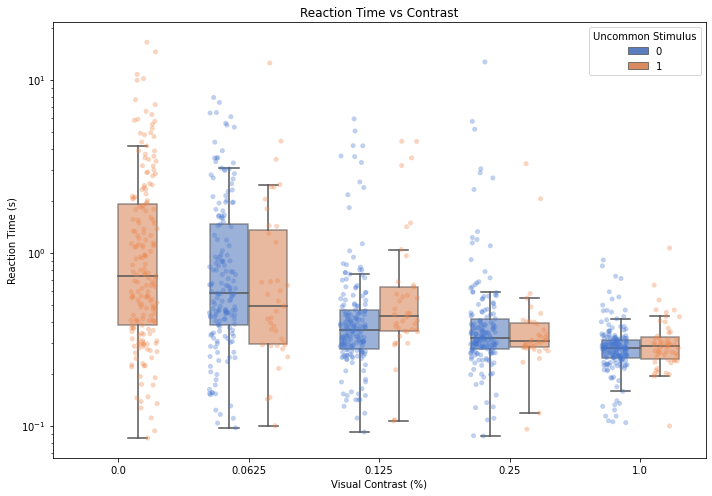

In [36]:
# Create a single figure and axis
fig, ax = plt.subplots(figsize=(10, 7))

# 1. Plot the jittered scatter points first
sns.stripplot(
    data=biased_trials,
    x="contrast",
    y="reaction_time",
    hue="uncommon_stimulus",
    dodge=True,  # Separates categories horizontally
    alpha=0.35,  # Makes dots translucent to show density
    jitter=0.2,  # Spreads points laterally
    palette="muted",
    ax=ax,
)

# 2. Superimpose the Boxplot directly on top
sns.boxplot(
    data=biased_trials,
    x="contrast",
    y="reaction_time",
    hue="uncommon_stimulus",
    dodge=True,  # Must match the stripplot's dodge
    width=0.6,  # Slightly narrower boxes
    fliersize=0,  # Prevents drawing outliers twice
    palette="muted",
    boxprops=dict(alpha=0.6),  # Translucent boxes so points remain visible
    ax=ax,
)

# 3. Clean up the duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Uncommon Stimulus")

# Formatting the axis
ax.set_title("Reaction Time vs Contrast")
ax.set_xlabel("Visual Contrast (%)")
ax.set_ylabel("Reaction Time (s)")
ax.set_yscale("log")  # Using log scale to handle right-skewed reaction times

plt.tight_layout()
plt.show()

In [43]:
# Group by contrast and uncommon_stimulus, then calculate the proportion of correct trials
accuracy_data = (
    biased_trials.groupby(["contrast", "uncommon_stimulus"])["feedbackType"]
    .apply(lambda x: (x == 1).mean())
    .reset_index(name="accuracy")
)

# Display the resulting DataFrame
print(accuracy_data)

   contrast  uncommon_stimulus  accuracy
0    0.0000                  1  0.571429
1    0.0625                  0  0.767857
2    0.0625                  1  0.538462
3    0.1250                  0  0.917127
4    0.1250                  1  0.825000
5    0.2500                  0  0.982759
6    0.2500                  1  0.921053
7    1.0000                  0  0.988701
8    1.0000                  1  0.963636


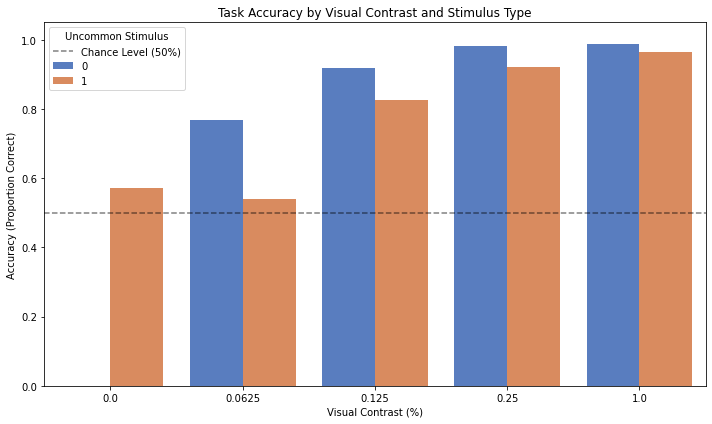

In [45]:
# Initialize the plot layout
plt.figure(figsize=(10, 6))

# Create the barplot
sns.barplot(
    data=accuracy_data,
    x="contrast",
    y="accuracy",
    hue="uncommon_stimulus",
    palette="muted",
)

# Add a baseline chance level line at 50% accuracy
plt.axhline(
    0.5, color="black", linestyle="--", alpha=0.5, label="Chance Level (50%)"
)

# Formatting adjustments
plt.title("Task Accuracy by Visual Contrast and Stimulus Type")
plt.xlabel("Visual Contrast (%)")
plt.ylabel("Accuracy (Proportion Correct)")
plt.ylim(0, 1.05)  # Constrain Y-axis from 0% to just past 100%

# Re-draw the legend to cleanly combine the bars and the chance line
plt.legend(title="Uncommon Stimulus")

plt.tight_layout()
plt.show()

In [ ]:
# Inspect the distribution of uncommon_stimulus for trials with 0 contrast
biased_trials[biased_trials['contrast'] == 0]['uncommon_stimulus'].value_counts()

uncommon_stimulus
1    189
Name: count, dtype: int64

Using this data we can plot the psychometric curve and compute some performance metrics, for example the number of trials in the session or the performance of the mouse on easy trials (50% and 100% contrast)

Number of trials for session a4f7079b-d157-4de9-ba80-de9a98f35c8b: 682
Performance easy for session a4f7079b-d157-4de9-ba80-de9a98f35c8b: 0.9457364341085271


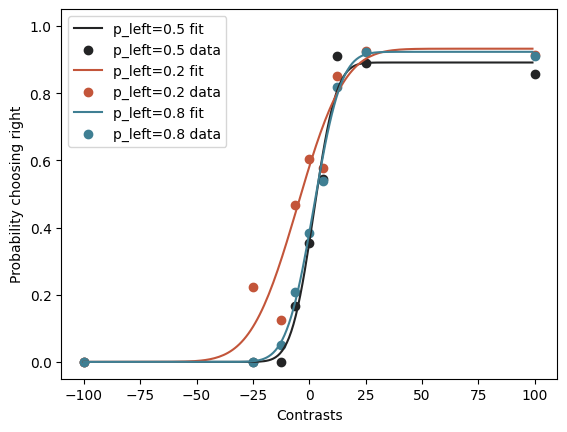

In [45]:
from brainbox.behavior.training import plot_psychometric, compute_n_trials, compute_performance_easy, compute_performance

plot_psychometric(trials)
n_trials = compute_n_trials(trials)
perf_easy = compute_performance_easy(trials)
print(f'Number of trials for session {sess}: {n_trials}')
print(f'Performance easy for session {sess}: {perf_easy}')

## Combining training criteria

Another [dataset](https://docs.google.com/document/d/1OqIqqakPakHXRAwceYLwFY9gOrm8_P62XIfCTnHwstg/edit#heading=h.18vu2zskyq0r) is available that contains information about the session at which the subject reached certain training criteria in the IBL training pipeline. More information can be found about the training pipeline in the study [A standardized and reproducible method to measure decision-making in mice](https://doi.org/10.1101/2020.01.17.909838).

We can download this dataset in the following way

In [46]:
subject_training = load_aggregate(subject, '_ibl_subjectTraining.table.pqt')

We can combine this with our subject trials table to see how the subject progressed

In [47]:
subject_trials = (subject_trials
          .join(subject_training.set_index('session'))
          .sort_values(by=['session_start_time', 'intervals_0']))
subject_trials['training_status'] = subject_trials.training_status.fillna(method='ffill')

Our subject trials table now has a new column that indicates the training criteria of the mouse at each session. We can use this information to make a plot of how the performance of the mouse improved across training days.

We will need to compute the performance per session and add this column to our dataframe and also add in a column for training day.

In [48]:
sessions = subject_trials.index.unique()
for n_sess, sess in enumerate(sessions):
  trials = subject_trials[subject_trials.index == sess]
  perf_easy = compute_performance_easy(trials)
  subject_trials.loc[subject_trials.index == sess, 'performance_easy'] = perf_easy
  subject_trials.loc[subject_trials.index == sess, 'training_day'] = n_sess

Note since we already ordered by session_start_time above our table was already sorted. Here we have simply assigned each training session to a training day but there are some cases where multiple training sessions were run on the same day so this may be something you want to account for in your analysis.

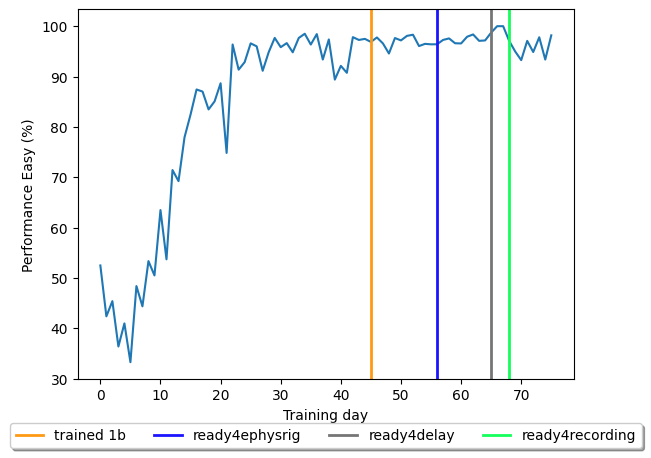

In [49]:
import matplotlib.pyplot as plt
from ibllib.pipes.training_status import TRAINING_STATUS
fig, ax = plt.subplots(1, 1)
ax.plot(subject_trials['training_day'], subject_trials['performance_easy'] * 100)
ax.set_xlabel("Training day")
ax.set_ylabel("Performance Easy (%)")
status = subject_trials.drop_duplicates(subset='training_status', keep='first')
for _, st in status.iterrows():
    if st['training_status'] in ['untrainable', 'unbiasable']:
        continue
    if TRAINING_STATUS[st['training_status']][0] <= 0:
        continue
    ax.axvline(st['training_day'], linewidth=2,
               color=np.array(TRAINING_STATUS[st['training_status']][1]) / 255, label=st['training_status'])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
                   fancybox=True, shadow=True, ncol=5)

# Combining data across multiple subjects

We can loop over all the subjects available to get a large dataframe that contains the data for all the subjects. Here is an example of how this can be done


In [25]:
import pandas as pd

all_trials = []

# Download two tables, subject trials table and subject training table and combine
for i, subject in enumerate(subjects):
  if np.mod(i, 50) == 0:
    print(f'{i}/{len(subjects)}')

  # Load trials table for subject
  subject_trials = load_aggregate(subject, '_ibl_subjectTrials.table.pqt')

  # Load sessions table for subject
  session_trials = load_aggregate(subject, '_ibl_subjectSessions.table.pqt')

  # Load training status for subject
  subject_training = load_aggregate(subject, '_ibl_subjectTraining.table.pqt')

  # Combine the two tables
  subject_trials = (subject_trials
            .set_index('session')
            .join(subject_training.set_index('session'))
            .sort_values(by=['session_start_time', 'intervals_0']))
  subject_trials['training_status'] = subject_trials.training_status.fillna(method='ffill')

  # Join sessions table for number, task_protocol, etc.
  if 'task_protocol' in subject_trials:
      subject_trials = subject_trials.drop('task_protocol', axis=1)
  subject_trials = subject_trials.join(session_trials.drop('date', axis=1))

  # Sort the trials by session start time and trial number
  subject_trials = subject_trials.sort_values(by=['session_start_time', 'intervals_0'])


  # add in extra columns for performance easy and training day
  sessions = subject_trials.index.unique()
  for n_sess, sess in enumerate(sessions):
    trials = subject_trials[subject_trials.index == sess]
    perf_easy = compute_performance_easy(trials)
    subject_trials.loc[subject_trials.index == sess, 'performance_easy'] = perf_easy
    subject_trials.loc[subject_trials.index == sess, 'training_day'] = n_sess


  all_trials.append(subject_trials)

all_trials = pd.concat(all_trials)

0/140


/usr/local/lib/python3.12/dist-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL045/#2024-04-10#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL046/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL046/#2024-08-21#/_ibl_subjectTrials.table.pqt: 100%|██████████| 11.1M/11.1M [00:00<00:00, 11.5MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL046/_ibl_subjectSessions.table.pqt: 100%|██████████| 10.2k/10.2k [00:00<00:00, 50.1kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL046/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.26k/3.26k [00:00<00:00, 17.3kB/s]

Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL_001/_ibl_subjectSessions.table.9291b9e8-d1eb-4952-a780-f71e00250d1b.pqt Bytes: 9424


100%|██████████| 0.0089874267578125/0.0089874267578125 [00:00<00:00, 15.11it/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL_001/#2024-08-21#/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.19k/3.19k [00:00<00:00, 14.2kB/s]
/usr/local/lib/python3.12/dist-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL_002/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL_002/#2024-08-21#/_ibl_subjectTrials.table.pqt: 100%|██████████| 9.16M/9.16M [00:00<00:00, 9.60MB/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL_002/_ibl_subjectSessions.table.37b5f24f-84df-4e3c-8286-6699891f8c3c.pqt Bytes: 9364


...

Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mrsicflogellab/IBL_002/_ibl_subjectSessions.table.9ac5f6f9-78b4-44a5-afe6-a2379ed6062c.pqt Bytes: 7968


100%|██████████| 0.007598876953125/0.007598876953125 [00:00<00:00,  9.95it/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mrsicflogellab/IBL_002/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.08k/3.08k [00:00<00:00, 15.7kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/cortexlab/KS002/_ibl_subjectTrials.table.pqt: 100%|██████████| 7.58M/7.58M [00:00<00:00, 8.28MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/cortexlab/KS002/_ibl_subjectSessions.table.pqt: 100%|██████████| 9.53k/9.53k [00:00<00:00, 50.2kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/cortexlab/KS002/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.26k/3.26k [00:00<00:00, 16.7kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/cortexlab/KS004/_ibl_subjectTrials.table.pqt: 100%|██████████| 4.52M/4.52M [00:00<00:00, 5.56MB/s]
(S3) /root/Dow

100/140


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1092/_ibl_subjectTrials.table.pqt: 100%|██████████| 1.57M/1.57M [00:00<00:00, 2.30MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1092/_ibl_subjectSessions.table.pqt: 100%|██████████| 6.52k/6.52k [00:00<00:00, 31.0kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1092/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.08k/3.08k [00:00<00:00, 15.6kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1093/_ibl_subjectTrials.table.pqt: 100%|██████████| 1.28M/1.28M [00:00<00:00, 1.85MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1093/_ibl_subjectSessions.table.pqt: 100%|██████████| 6.33k/6.33k [00:00<00:00, 33.1kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab

KeyboardInterrupt: 

Once we have this large training table aggregated across all subjects we can manipulate this table to view different properties. For example we can see how the pyshcometric curves varies across the different training stages across all subjects

<Axes: xlabel='signed_contrast', ylabel='choice'>

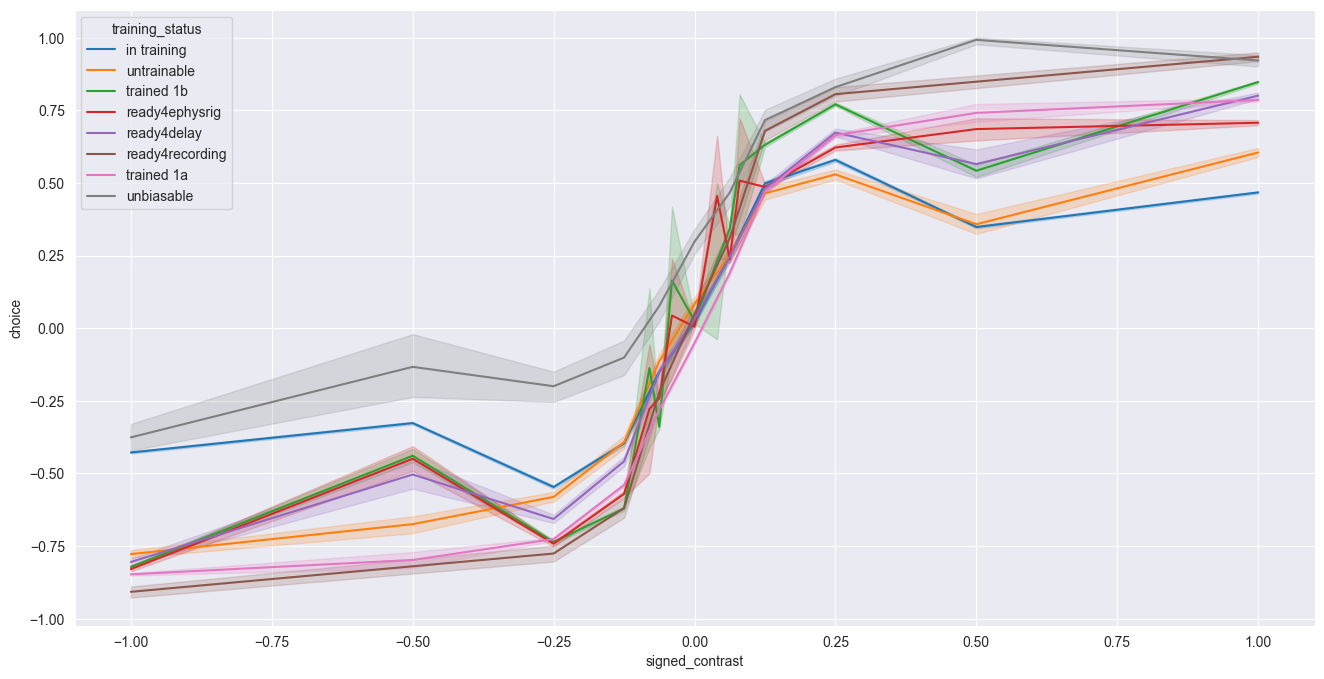

In [ ]:
import seaborn as sns
# plot psychometric curves for the whole dataframe
all_trials = all_trials.reset_index()
all_trials['signed_contrast'] = np.nan
i = np.isnan(all_trials['contrastRight'])
all_trials.loc[i , 'signed_contrast'] = all_trials.loc[i, 'contrastLeft']
all_trials.loc[~i, 'signed_contrast'] = - all_trials.loc[~i, 'contrastRight']

fig, ax = plt.subplots(1, 1, sharex=True, figsize=(16, 8))
sns.lineplot(data=all_trials.loc[all_trials['probabilityLeft'] == 0.5], x='signed_contrast', y='choice', hue='training_status', ax=ax)

Or we can look how the performance on easy trial progresses over training days across labs

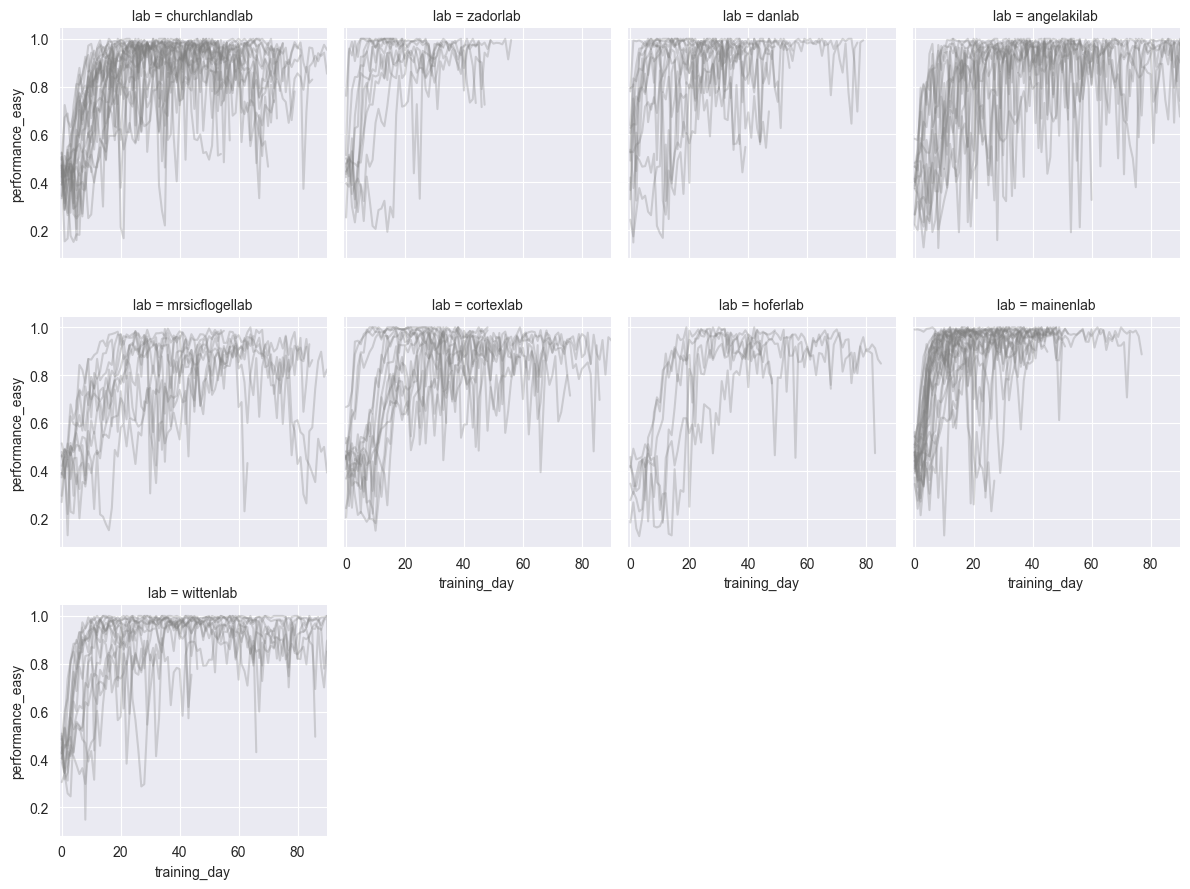

In [ ]:
# Remove duplicate rows that we don't need for the plots
fig = sns.FacetGrid(all_trials.drop_duplicates('session'),
                    col="lab", col_wrap=4,
                    sharex=True, sharey=True, aspect=1, hue="subject", xlim=[-1, 90])
fig.map(sns.lineplot, "training_day",
        "performance_easy", color='gray', alpha=0.3)

# Additional resources

Documentation

- [ONE documentation](https://int-brain-lab.github.io/iblenv/notebooks_external/one_quickstart.html#)
- [Getting started with ONE](https://colab.research.google.com/drive/1y3sRI1wC7qbWqN6skvulzPOp6xw8tLm7)
- [Loading trials data](https://int-brain-lab.github.io/iblenv/notebooks_external/loading_trials_data.html)


Where can I find help?
- Issues with the data? Post an issue here: https://neurostars.org/ with the tag `ibl`
- Alternatively post an issue here: https://github.com/int-brain-lab/iblenv/issues
- General questions about the datasets or publications? Email: info@internationalbrainlab.org




> *All data are made available under the CC BY 4.0 license.*